#### Anlea Maria Jose, SE AIML, Roll No.: 02
#### Experiment 8: Clustering of Countries with World Bank API
#### Date: 11-03-2026

In [19]:
!pip install requests

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

#### Part 1: Fetching data with World Bank API

In [21]:
def fetch_indicator(code, year="2023"):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}/?data={year}&format=json&per_page=30000"
    response = requests.get(url).json()[1]
    data = {}
    
    for item in response:
        country = item["country"]["value"]
        value = item["value"]
        if value is not None:
            data[country]=value
    return pd.Series(data, name=code)

In [22]:
gdp = fetch_indicator("NY.GDP.PCAP.CD")
pop = fetch_indicator("SP.POP.TOTL")
life = fetch_indicator("SP.DYN.LE00.IN")
lit = fetch_indicator("SE.ADT.LITR.ZS")

In [23]:
df = pd.concat([gdp, pop, life, lit], axis=1)

# Define new column name
df.columns = ["GDP", "Population", "LifeExpectancy", "Literacy"]

# Remove missing values
df.dropna(inplace=True)
df.head()

,GDP,Population,LifeExpectancy,Literacy
Africa Eastern and Southern,186.089204,130075728,44.169658,56.846149
Africa Western and Central,121.936832,97630925,37.779636,40.234791
Arab World,212.904079,91540853,44.794056,48.319962
Caribbean small states,455.490442,2558348,60.296076,86.809372
Central Europe and the Baltics,2457.174549,91401309,67.943473,97.965279


In [24]:
df.tail()

,GDP,Population,LifeExpectancy,Literacy
Viet Nam,238.647805,32531933,58.046,83.830002
West Bank and Gaza,1201.581542,1978248,67.803,86.080002
"Yemen, Rep.",910.422466,5532301,33.462,37.090000
Zambia,221.559849,3153729,50.648,65.000000
Zimbabwe,276.560896,3809389,53.492,77.790001


In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

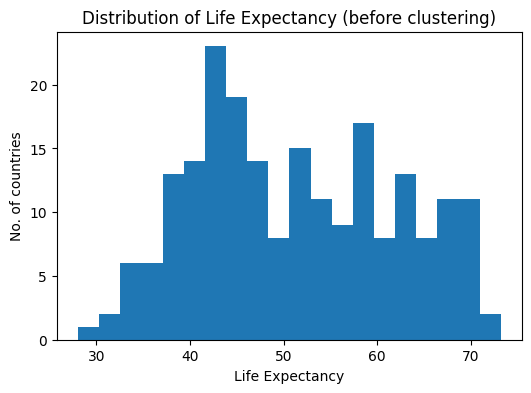

In [29]:
plt.figure(figsize=(6,4))
plt.hist(df["LifeExpectancy"], bins=20)
plt.xlabel("Life Expectancy")
plt.ylabel("No. of countries")
plt.title("Distribution of Life Expectancy (before clustering)")
plt.show()

#### Part 2: Elbow Method

k	WCSS
1 	 844.0
2 	 533.6268707205747
3 	 372.6600645940388
4 	 230.71239142256888
5 	 194.5121909247295
6 	 160.39628065787593
7 	 111.93634231466007
8 	 89.92067437215351
9 	 86.08319291796424
10 	 73.17241237376219


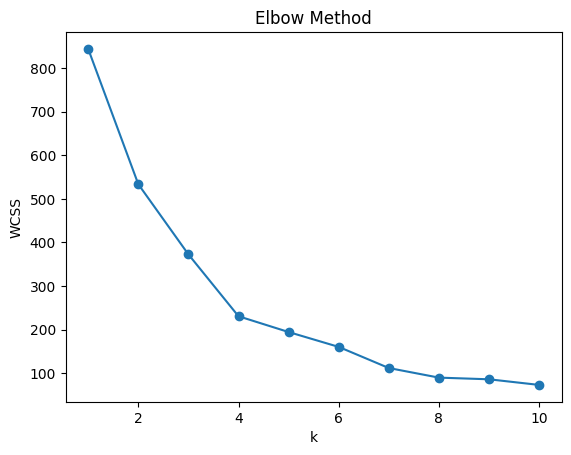

In [32]:
wcss = []
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    
print("k\tWCSS")

for i in range(10):
    print(i+1, "\t", wcss[i])
    
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

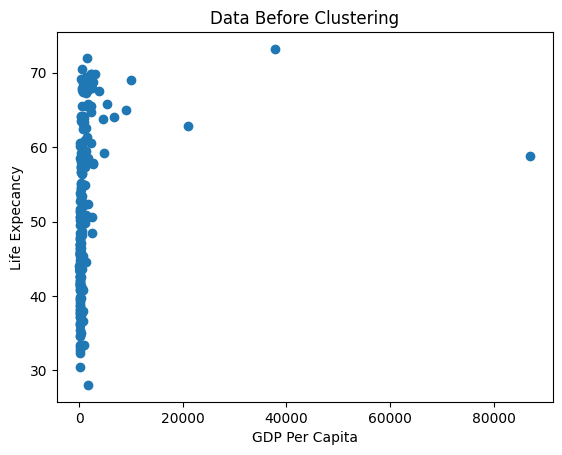

In [35]:
plt.scatter(df["GDP"], df["LifeExpectancy"])
plt.xlabel("GDP Per Capita")
plt.ylabel("Life Expecancy")
plt.title("Data Before Clustering")
plt.show()

In [36]:
kmeans = KMeans(n_clusters=3, random_state=0)
labels_km = kmeans.fit_predict(X_scaled)
df["KMeansCluster"] = labels_km

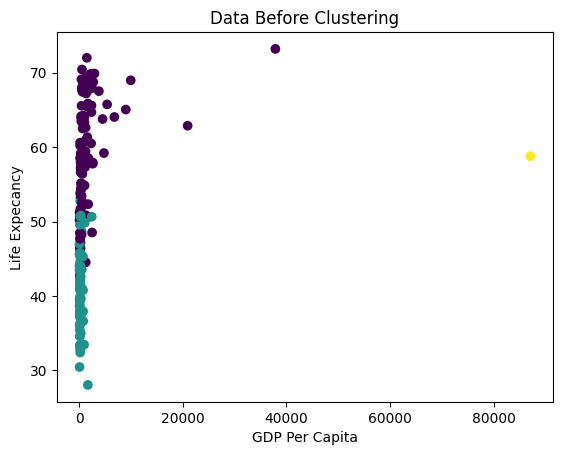

In [37]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c=labels_km)
plt.xlabel("GDP Per Capita")
plt.ylabel("Life Expecancy")
plt.title("Data Before Clustering")
plt.show()

In [42]:
# Hierarchical Cluster
hc = AgglomerativeClustering(n_clusters=3)
labels_hc = hc.fit_predict(X_scaled)
df["HierarchicalCluster"] = labels_hc

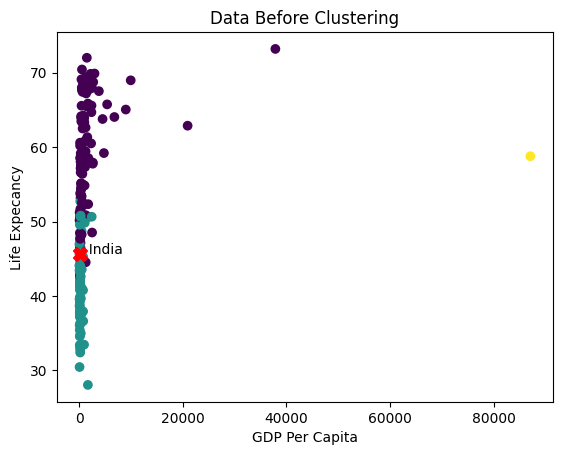

In [68]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c=labels_km)
plt.xlabel("GDP Per Capita")
plt.ylabel("Life Expecancy")
plt.title("Data Before Clustering")
india = df.loc["India"]
plt.scatter(india["GDP"], india["LifeExpectancy"],
           s=100, color='Red', marker='X')
plt.text(india["GDP"], india["LifeExpectancy"], "  India")
plt.show()

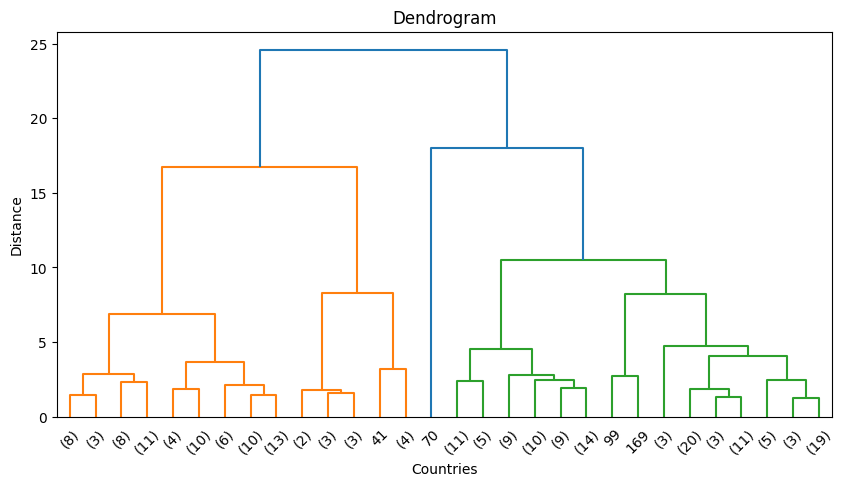

In [46]:
linked=linkage(X_scaled, method="ward")
plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.xlabel("Countries")
plt.ylabel("Distance")
plt.title("Dendrogram")
plt.show()

In [49]:
country_name = "India"

result = df.loc[country_name]
print("Country: ", country_name)
print("GDP per Capita: ", result["GDP"])
print("Population: ", result["Population"])
print("Life Expectancy: ", result["LifeExpectancy"])
print("Literacy Rate: ", result["Literacy"])
print("KMeans Cluster: ", result["KMeansCluster"])
print("Hierarchical Cluster: ", result["HierarchicalCluster"])

Country:  India
GDP per Capita:  84.9328084793106
Population:  435990338.0
Life Expectancy:  45.61
Literacy Rate:  40.7599983215332
KMeans Cluster:  1.0
Hierarchical Cluster:  0.0


In [60]:
country_name = ["North America", "Brazil", "Bahrain", "Viet Nam"]

for i in range(4):
    result = df.loc[country_name[i]]
    print("\nCountry: ", country_name[i])
    print("GDP per Capita: ", result["GDP"])
    print("Population: ", result["Population"])
    print("Life Expectancy: ", result["LifeExpectancy"])
    print("Literacy Rate: ", result["Literacy"])
    print("KMeans Cluster: ", result["KMeansCluster"])
    print("Hierarchical Cluster: ", result["HierarchicalCluster"])


Country:  North America
GDP per Capita:  2933.32612076162
Population:  198622564.0
Life Expectancy:  69.8928809447431
Literacy Rate:  98.6211624145508
KMeans Cluster:  0.0
Hierarchical Cluster:  1.0

Country:  Brazil
GDP per Capita:  235.266009502589
Population:  72388126.0
Life Expectancy:  53.162
Literacy Rate:  74.5899963378906
KMeans Cluster:  0.0
Hierarchical Cluster:  1.0

Country:  Bahrain
GDP per Capita:  1741.82245407152
Population:  165477.0
Life Expectancy:  50.634
Literacy Rate:  69.75
KMeans Cluster:  0.0
Hierarchical Cluster:  1.0

Country:  Viet Nam
GDP per Capita:  238.647805313403
Population:  32531933.0
Life Expectancy:  58.046
Literacy Rate:  83.8300018310547
KMeans Cluster:  0.0
Hierarchical Cluster:  1.0


In [62]:
cluster_summary = df.groupby("KMeansCluster")[["GDP", "Population", "LifeExpectancy", "Literacy"]].mean()
print(cluster_summary)

                        GDP    Population  LifeExpectancy   Literacy
KMeansCluster                                                       
0               1702.660957  4.045442e+07        59.53723  89.129141
1                236.373395  2.416630e+08        41.85457  47.763507
2              87085.094587  8.428000e+03        58.78200  98.870003
